# Autoencoder kao binarni klasifikator (sum vs. vozilo)

Cilj ove biljeznice je binarni klasifikator koji odgovara na pitanje **"je li ovo sum ili
nije?"**, implementiran kao **autoencoder** (teorija: `neuronske_mreze_teorija.ipynb`, sekcija 4).

Podaci su vec izolirani u dvije mape:
- `data/raw/background` - pozadinski sum (klasa "sum")
- `data/raw/vehicle` - zvuk vozila (klasa "vozilo")

**Kljucna razlika od svih ostalih modela u ovoj mapi** (Bayes, Decision Tree, Random Forest,
XGBoost): tamo su oba modela vidjela obje klase u treningu (standardni supervised pristup).
Ovdje autoencoder u treningu vidi **iskljucivo** `background` (sum) - nikad ne vidi primjer
vozila dok uci. Mreza nauci rekonstruirati "izgled" suma; kad joj damo zvuk vozila (koji nikad
nije vidjela), rekonstrukcija je losa, a ta greska rekonstrukcije postaje signal za
klasifikaciju (**[VIDJETI izvori/izvor17.md]**, Sakurada & Yairi, 2014).

**Napomena o `scripts/legacy/`:** u legacy kodu (`Classify_Data_2.py`) vec postoji binarni
klasifikator BG vs. Veh, ali to je **supervised CNN nad spektrogram slikama** (2D konvolucije,
obje klase oznacene u treningu) - drugaciji pristup od naseg, ne autoencoder. Usporedba
pristupa je u sekciji 4 ove biljeznice.

In [1]:
import os

import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from scipy.stats import linregress

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, balanced_accuracy_score,
)

BG_PATH = '../../data/raw/background'
VEH_PATH = '../../data/raw/vehicle'


## Pretprocesiranje i ekstrakcija znacajki

Identican pipeline kao u `decision_tree.ipynb` / `random_forest.ipynb` / `xgboost_model.ipynb`
(notch filter za mrezni hum + high-pass, pa isti prosireni set znacajki) - kopiran ovdje radi
izravne usporedivosti izmedju modela, bez ponovnog objasnjavanja EDA dijela (taj je vec
napravljen u glavnoj EDA analizi).

In [2]:
def remove_mains_hum(y, sr, hum_freqs=(50, 100, 150, 200), Q=30):
    """Uski notch filter na mreznoj frekvenciji i njenim harmonicima."""
    y_filt = y.copy()
    for f0 in hum_freqs:
        if f0 >= sr / 2:
            continue
        b, a = signal.iirnotch(f0, Q, sr)
        y_filt = signal.filtfilt(b, a, y_filt)
    return y_filt


def highpass(y, sr, cutoff=15, order=4):
    """Blagi high-pass da uklonimo vrlo niske frekvencije koje mogu biti samo sum."""
    sos = signal.butter(order, cutoff, btype='highpass', fs=sr, output='sos')
    return signal.sosfiltfilt(sos, y)


def preprocess(y, sr):
    y = remove_mains_hum(y, sr)
    y = highpass(y, sr)
    return y


In [3]:
LOW_BAND = (0, 300)
MID_BAND = (300, 2000)
HIGH_BAND = (2000, 11025)


def fft_psd(y, sr):
    window = np.hanning(len(y))
    y_win = y * window

    fft = np.fft.rfft(y_win)
    psd = np.abs(fft) ** 2

    freqs = np.fft.rfftfreq(len(y), 1 / sr)
    return freqs, psd


def band_energy_ratios(freqs, psd):
    total = psd.sum() + 1e-12

    def band_frac(lo, hi):
        mask = (freqs >= lo) & (freqs < hi)
        return psd[mask].sum() / total

    return band_frac(*LOW_BAND), band_frac(*MID_BAND), band_frac(*HIGH_BAND)


def spectral_slope(freqs, psd, f_min=20, f_max=4000):
    mask = (freqs >= f_min) & (freqs <= f_max) & (psd > 0)
    if mask.sum() < 2:
        return 0.0
    log_f = np.log10(freqs[mask])
    log_p = np.log10(psd[mask])
    slope, _, _, _, _ = linregress(log_f, log_p)
    return slope


def bandwidth_low_band(freqs, psd):
    lo, hi = LOW_BAND
    mask = (freqs >= lo) & (freqs < hi)
    f = freqs[mask]
    p = psd[mask]
    if p.sum() <= 0:
        return 0.0
    centroid = np.average(f, weights=p)
    return np.sqrt(np.average((f - centroid) ** 2, weights=p))


def extract_features(y, sr):
    freqs, psd = fft_psd(y, sr)

    rms = np.mean(librosa.feature.rms(y=y))
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))
    centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))
    rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
    low_e, mid_e, high_e = band_energy_ratios(freqs, psd)
    slope = spectral_slope(freqs, psd)
    bw_low = bandwidth_low_band(freqs, psd)

    onset_env = librosa.onset.onset_strength(y=y, sr=sr)
    flux = np.abs(np.diff(onset_env))

    flatness = librosa.feature.spectral_flatness(y=y)[0]

    y_harm, y_perc = librosa.effects.hpss(y)
    harm_energy = np.sum(y_harm ** 2)
    perc_energy = np.sum(y_perc ** 2)
    harmonic_ratio = harm_energy / (harm_energy + perc_energy + 1e-12)

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=5)

    feats = {
        'rms': rms,
        'zcr': zcr,
        'spectral_centroid': centroid,
        'spectral_bandwidth': bandwidth,
        'spectral_rolloff': rolloff,
        'low_band_energy': low_e,
        'mid_band_energy': mid_e,
        'high_band_energy': high_e,
        'spectral_slope': slope,
        'bandwidth_low_band': bw_low,
        'flux_mean': np.mean(flux),
        'flux_std': np.std(flux),
        'spectral_flatness_mean': np.mean(flatness),
        'spectral_flatness_std': np.std(flatness),
        'harmonic_ratio': harmonic_ratio,
    }

    for i in range(5):
        feats[f'mfcc_{i}_mean'] = np.mean(mfcc[i])
        feats[f'mfcc_{i}_std'] = np.std(mfcc[i])

    return feats


In [4]:
CACHE_PATH = '../../data/features_cache/znacajke_cache_bg_veh.pkl'

if os.path.exists(CACHE_PATH):
    # Znacajke su vec izracunate i spremljene - samo ucitamo gotov DataFrame
    df = pd.read_pickle(CACHE_PATH)
    print(f"Znacajke ucitane iz cachea: {CACHE_PATH} ({len(df)} uzoraka)")
else:
    data = []
    sources = [(BG_PATH, 'background'), (VEH_PATH, 'vehicle')]

    for folder, label in sources:
        files = [f for f in os.listdir(folder) if f.endswith('.wav')]

        for i, file in enumerate(files):
            path = os.path.join(folder, file)

            if i % 500 == 0:
                print(f"   {label}: {i}/{len(files)} -> {file}")

            y, sr = librosa.load(path, sr=None)
            y = y[:sr * 2]  # CLIP_SECONDS = 2
            y = preprocess(y, sr)

            feats = extract_features(y, sr)
            feats['file'] = file
            feats['label'] = label
            data.append(feats)

    print(f"\nGotovo! Ukupno uzoraka: {len(data)}")

    df = pd.DataFrame(data)
    df = df[[c for c in df.columns if c not in ('file', 'label')] + ['file', 'label']]
    df.to_pickle(CACHE_PATH)
    print(f"Znacajke spremljene u cache: {CACHE_PATH}")

print("\nBroj uzoraka po klasi:")
print(df['label'].value_counts())

feature_cols = [c for c in df.columns if c not in ('file', 'label')]
df.head()


Znacajke ucitane iz cachea: ../../data/features_cache/znacajke_cache_bg_veh.pkl (19460 uzoraka)

Broj uzoraka po klasi:
label
vehicle       13668
background     5792
Name: count, dtype: int64


,rms,zcr,spectral_centroid,spectral_bandwidth,spectral_rolloff,low_band_energy,mid_band_energy,high_band_energy,spectral_slope,bandwidth_low_band,...,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,mfcc_4_std,file,label
0,0.015549,0.036304,1904.237022,2797.868011,3650.639960,0.584443,0.370418,0.045020,-1.631526,72.947420,...,192.713506,9.538895,-38.746474,8.422422,33.475851,5.947687,2.531960,5.494298,BG_Fitzroy1_2024-02-09_13-1-10.0_63.6_2Lanes.wav,background
1,0.007586,0.026611,1598.075689,2847.859498,2658.286237,0.694093,0.290129,0.015729,-2.121370,77.433672,...,209.683810,9.743657,-27.274918,7.684898,18.237884,4.059019,6.947345,6.106640,BG_Fitzroy1_2024-02-09_13-10-35.7_621.2_2Lanes...,background
2,0.023253,0.203307,3240.057964,5152.990390,7224.235372,0.688464,0.151852,0.027625,-1.667870,64.490967,...,178.606450,18.587330,-24.631244,12.923045,32.721899,6.947611,2.418585,8.355309,BG_Fitzroy1_2024-02-09_13-0-40.9_35.4_2Lanes.wav,background
3,0.014056,0.030658,1710.363949,2666.181079,3222.656250,0.614416,0.351425,0.034097,-1.776314,66.135407,...,197.120504,11.613464,-30.170872,8.914245,31.807294,7.072448,6.976703,6.802411,BG_Fitzroy1_2024-02-09_13-10-18.2_609.2_2Lanes...,background
4,0.010144,0.028570,1673.865206,2729.003827,3096.991356,0.624640,0.350276,0.025042,-1.876599,68.264893,...,204.029060,10.618098,-33.595783,6.896383,29.556164,7.701917,7.110093,6.037491,BG_Fitzroy1_2024-02-09_13-10-18.2_612.2_2Lanes...,background


## 1. Priprema podataka za autoencoder (trening iskljucivo na "sumu")

Za razliku od svih dosadasnjih modela u ovoj mapi, ovdje **ne dijelimo** obje klase zajedno
u train/test. Umjesto toga:

- `background` (sum) dijelimo na train / validation / test (60% / 20% / 20%)
- `vehicle` (vozilo) **u cijelosti** ide u evaluaciju - autoencoder ga nikad ne vidi u treningu

`StandardScaler` se fitta **iskljucivo na `background` train skupu** (isto nacelo kao i sam
autoencoder - sve sto model "vidi" u fazi ucenja dolazi samo iz klase suma).

In [5]:
df_bg = df[df['label'] == 'background'][feature_cols].reset_index(drop=True)
df_veh = df[df['label'] == 'vehicle'][feature_cols].reset_index(drop=True)

bg_train, bg_temp = train_test_split(df_bg, test_size=0.4, random_state=42)
bg_val, bg_test = train_test_split(bg_temp, test_size=0.5, random_state=42)

scaler = StandardScaler()
X_bg_train = scaler.fit_transform(bg_train)
X_bg_val = scaler.transform(bg_val)
X_bg_test = scaler.transform(bg_test)
X_veh_test = scaler.transform(df_veh)

print(f"Background - train: {len(bg_train)}, val: {len(bg_val)}, test: {len(bg_test)}")
print(f"Vehicle (samo za evaluaciju/threshold): {len(df_veh)}")
print(f"Broj znacajki na ulazu: {X_bg_train.shape[1]}")


Background - train: 3475, val: 1158, test: 1159
Vehicle (samo za evaluaciju/threshold): 13668
Broj znacajki na ulazu: 25


## 2. Arhitektura autoencodera

Simetrican encoder/decoder oko uskog bottlenecka: 25 ulaznih znacajki -> 16 -> 8 (bottleneck)
-> 16 -> 25 izlaznih (rekonstrukcija). ReLU aktivacije u skrivenim slojevima, linearni izlaz. Loss = MSE
(minimiziramo razliku izmedju ulaza i rekonstrukcije).

`EarlyStopping` na validacijskom gubitku (i dalje samo na `background` validaciji) sprjecava
overfitting i vraca tezine iz najbolje epohe.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 25)             │           425 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

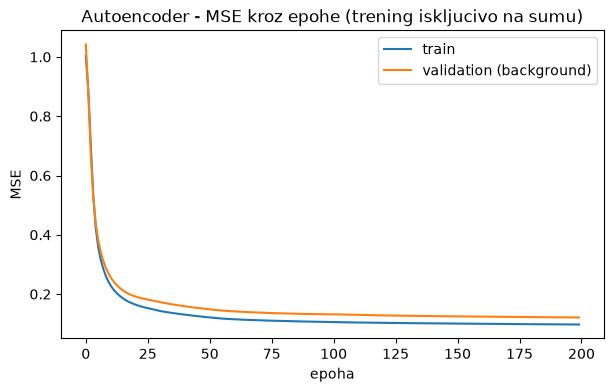

Broj odradjenih epoha (early stopping): 200


In [6]:
tf.keras.utils.set_random_seed(42)

n_features = X_bg_train.shape[1]

autoencoder = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(n_features,)),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),   # bottleneck
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(n_features, activation='linear'),
])
autoencoder.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss='mse')
autoencoder.summary()

early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True,) # ako nakon 15 epoha nema poboljsanja stoppas

history = autoencoder.fit(
    X_bg_train, X_bg_train,
    validation_data=(X_bg_val, X_bg_val),
    epochs=200, batch_size=64, callbacks=[early_stop], verbose=0,
)

plt.figure(figsize=(7, 4))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation (background)')
plt.title('Autoencoder - MSE kroz epohe (trening iskljucivo na sumu)')
plt.xlabel('epoha')
plt.ylabel('MSE')
plt.legend()
plt.show()

print(f"Broj odradjenih epoha (early stopping): {len(history.history['loss'])}")


## 3. Odabir praga (threshold) i binarna klasifikacija

Gresku rekonstrukcije (MSE po uzorku) racunamo na tri skupa koje mreza nije koristila za
azuriranje tezina: `bg_test` (sum, neviđen), `bg_val` (sum, koristen samo za early stopping,
ne za gradijente) i `veh_test` (vozilo, autoencoder ga nikad nije vidio).

Threshold biramo kao **95. percentil greske rekonstrukcije na `background` train skupu**
(isto nacelo kao u teorijskoj biljeznici, izvor17) - dakle threshold se odredjuje **iskljucivo
iz distribucije suma**, bez "prevare" gledanjem u vehicle podatke.

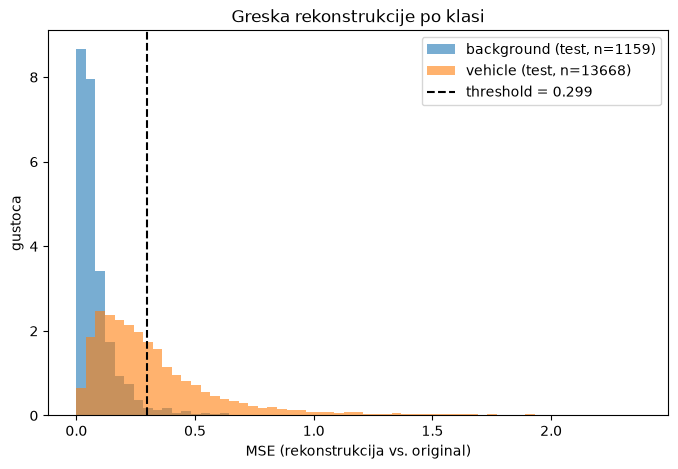

Threshold (95. percentil na background train gresci): 0.2987
Prosjecna greska - background test: 0.1013
Prosjecna greska - vehicle test:    0.3905


In [7]:
def reconstruction_error(model, X):
    X_hat = model.predict(X, verbose=0)
    return np.mean((X - X_hat) ** 2, axis=1)

err_bg_train = reconstruction_error(autoencoder, X_bg_train)
err_bg_test = reconstruction_error(autoencoder, X_bg_test)
err_veh_test = reconstruction_error(autoencoder, X_veh_test)

threshold = np.percentile(err_bg_train, 95)

plt.figure(figsize=(8, 5))
bins = np.linspace(0, np.percentile(np.concatenate([err_bg_test, err_veh_test]), 99), 60)
plt.hist(err_bg_test, bins=bins, alpha=0.6, label=f'background (test, n={len(err_bg_test)})', density=True)
plt.hist(err_veh_test, bins=bins, alpha=0.6, label=f'vehicle (test, n={len(err_veh_test)})', density=True)
plt.axvline(threshold, color='black', linestyle='--', label=f'threshold = {threshold:.3f}')
plt.title('Greska rekonstrukcije po klasi')
plt.xlabel('MSE (rekonstrukcija vs. original)')
plt.ylabel('gustoca')
plt.legend()
plt.show()

print(f"Threshold (95. percentil na background train gresci): {threshold:.4f}")
print(f"Prosjecna greska - background test: {err_bg_test.mean():.4f}")
print(f"Prosjecna greska - vehicle test:    {err_veh_test.mean():.4f}")

# ako pogledamo graf dolje vidjet cemo da je taj prag od 95 percentila ocigledno uzasan jer cak 40% vozila smatra sumom,
# zato pribjegavamo nacinu samostalnog odabira praga


                  precision    recall  f1-score   support

sum (background)       0.12      0.96      0.22      1159
vozilo (vehicle)       0.99      0.42      0.59     13668

        accuracy                           0.47     14827
       macro avg       0.56      0.69      0.41     14827
    weighted avg       0.92      0.47      0.56     14827



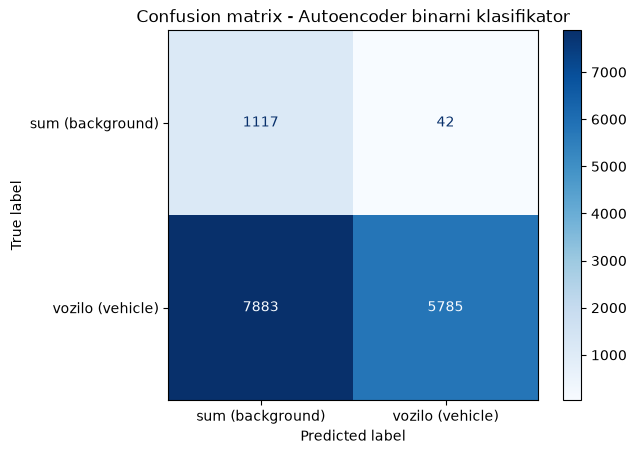

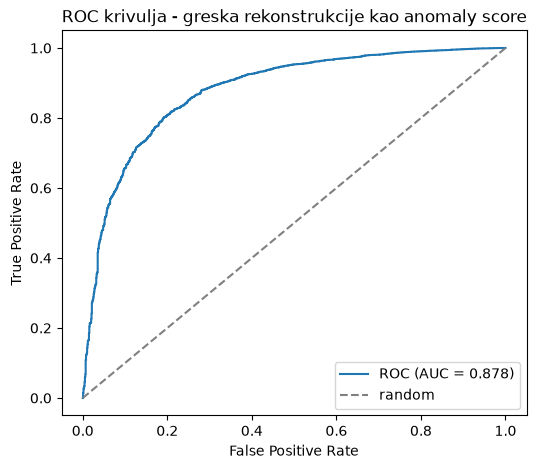

ROC-AUC: 0.878


In [11]:
# Binarna klasifikacija: greska > threshold => "vozilo", inace "sum"
y_true = np.concatenate([np.zeros(len(err_bg_test)), np.ones(len(err_veh_test))])
y_score = np.concatenate([err_bg_test, err_veh_test])
y_pred = (y_score > threshold).astype(int)

target_names = ['sum (background)', 'vozilo (vehicle)']
print(classification_report(y_true, y_pred, target_names=target_names))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap='Blues')
plt.title('Confusion matrix - Autoencoder binarni klasifikator')
plt.show()

auc = roc_auc_score(y_true, y_score)
fpr, tpr, _ = roc_curve(y_true, y_score)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC krivulja - greska rekonstrukcije kao anomaly score')
plt.legend()
plt.show()

print(f"ROC-AUC: {auc:.3f}")


### Je li 95. percentil dobar izbor praga?

ROC-AUC (iznad) mjeri koliko dobro sam **anomaly score** (greska rekonstrukcije) razdvaja
klase, neovisno o pragu. Ako je AUC znatno iznad 0.5, a metrike na 95. percentilu ispadnu
razocaravajuce, to je znak da threshold nije dobro kalibriran - ne da model ne razlikuje
klase. Provjerimo threshold koji maksimizira **Youdenov J statistic** (iz ROC krivulje, ideja je naci
tocku gdje model ima sto veci TPR a istovremeno sto manje FPR) na
istom test skupu, umjesto proizvoljnog 95. percentila iz teorije.

Napomena: ovdje "gledamo" u vozilo podatke da bismo izabrali prag - to je legitimno za
**evaluaciju/tuning praga** (isto kao sto bismo birali hiperparametar na validacijskom
skupu), ali autoencoder sam **i dalje nikad nije trenirao tezine** na vozilo podacima.

Threshold (95. percentil, iz teorije):  0.2987
Threshold (Youden's J, iz ROC krivulje): 0.1214

Klasifikacija s originalnim threshold-om (95. percentil): 
                  precision    recall  f1-score   support

sum (background)       0.12      0.96      0.22      1159
vozilo (vehicle)       0.99      0.42      0.59     13668

        accuracy                           0.47     14827
       macro avg       0.56      0.69      0.41     14827
    weighted avg       0.92      0.47      0.56     14827

-----------------------------------------------------------

Klasifikacija s optimalnim threshold-om (Youden's J): 
                  precision    recall  f1-score   support

sum (background)       0.26      0.81      0.39      1159
vozilo (vehicle)       0.98      0.80      0.88     13668

        accuracy                           0.80     14827
       macro avg       0.62      0.80      0.64     14827
    weighted avg       0.92      0.80      0.84     14827



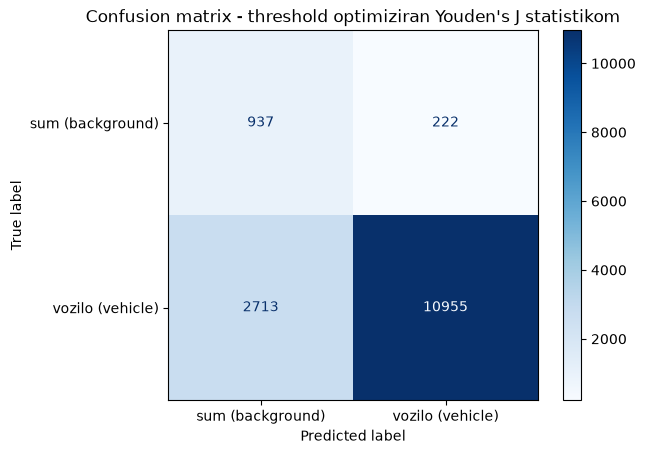

In [14]:
fpr, tpr, roc_thresholds = roc_curve(y_true, y_score)
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = roc_thresholds[best_idx]

y_pred_best = (y_score > best_threshold).astype(int)

print(f"Threshold (95. percentil, iz teorije):  {threshold:.4f}")
print(f"Threshold (Youden's J, iz ROC krivulje): {best_threshold:.4f}\n")

print("Klasifikacija s originalnim threshold-om (95. percentil): ")
print(classification_report(y_true, y_pred, target_names=target_names))
print("-----------------------------------------------------------")
print("")
print("Klasifikacija s optimalnim threshold-om (Youden's J): ")
print(classification_report(y_true, y_pred_best, target_names=target_names))

cm_best = confusion_matrix(y_true, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=target_names)
disp.plot(cmap='Blues')
plt.title("Confusion matrix - threshold optimiziran Youden's J statistikom")
plt.show()


## 4. Usporedba s postojecim (legacy) pristupom

U `scripts/legacy/Classify_Data_2.py` vec postoji binarni klasifikator BG vs. Veh, ali to
**nije autoencoder** - to je standardni **supervised CNN** koji radi nad spektrogram slikama:

| | `Classify_Data_2.py` (legacy CNN) | Ova biljeznica (autoencoder) |
|---|---|---|
| Ulaz | 2D spektrogram slika (163x223x3) | 1D feature-vektor (25 znacajki) |
| Trening | Vidi **obje** klase (BG i Veh) oznacene | Vidi **iskljucivo** `background` |
| Arhitektura | Conv2D slojevi + Dense + sigmoid izlaz | Dense encoder/decoder + bottleneck |
| Loss | Binary crossentropy (direktna klasifikacija) | MSE rekonstrukcije (indirektna klasifikacija) |
| Filozofija | Diskriminativni model - uci granicu izmedju klasa | Generativni/rekonstrukcijski - uci "izgled" jedne klase |

**Prednost autoencodera**: ne treba nam labeliran primjer "vozila" da bismo trenirali model
(samo za evaluaciju/threshold) - korisno ako u buducnosti zelimo detektirati i **nove**, jos
neviđene tipove zvuka koji nisu ni sum ni tipicno vozilo (npr. sirena, kocenje) kao anomalije,
sto klasican supervised klasifikator ne moze bez novih oznaka.

Mana: autoencoder pristup je u pravilu manje precizan od direktnog supervised klasifikatora
kad su obje klase dobro definirane i lako razdvojive (sto BG/Veh CNN iskoristava direktno).